In [1]:
#import
from torch import nn,optim
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
from matplotlib import pyplot as plt
import os
import copy
import math
import sys
import importlib
from tqdm.auto import tqdm

c:\Users\darwin5991\.conda\envs\phh\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 코랩 환경인지 확인하는 조건문
if 'google.colab' in sys.modules:
    print("현재 환경: Google Colab")
    # 코랩 전용 설정 (예: 드라이브 마운트)
    from google.colab import drive
    drive.mount('/content/drive')
    path='/content/drive/MyDrive/02_학업/02_연구 및 프로젝트/2512-2602_Dash 연구인턴/pytorch_practice'
    # path='/content/drive/MyDrive//pytorch_practice'
    sys.path.append(path)
else:
    print("현재 환경: Local Jupyter")
    # 로컬 전용 설정 (예: 경로 설정)
    # path = './'
    path = r'g:\내 드라이브\02_학업\02_연구 및 프로젝트\2512-2602_Dash 연구인턴\pytorch_practice'
# from my_module import *
import my_module as mm
print(f"작업 경로: {path}")

현재 환경: Local Jupyter
작업 경로: g:\내 드라이브\02_학업\02_연구 및 프로젝트\2512-2602_Dash 연구인턴\pytorch_practice


In [ ]:
importlib.reload(mm)
import my_module as mm

In [3]:
model_dir = os.path.join(path, 'download')
print(os.listdir(model_dir))

root=os.path.join(path, 'data','test')
os.makedirs(root, exist_ok=True)
print(os.listdir(root))

checkpoint_dir = os.path.join(path, 'checkpoints')
print(os.listdir(checkpoint_dir))

output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
print(os.listdir(output_dir))

DEVICE= 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'current device: {DEVICE}')

['cifar10_vgg16_bn-6ee7ea24.pt']
['cifar-10-batches-py', 'cifar-10-python.tar.gz']
['best_model.pt', 'CNN_CIFAR10_final_weights.pth', 'ckpt_ep1.pt', 'ckpt_ep2.pt', 'ckpt_ep3.pt', 'ckpt_ep5.pt', 'ckpt_ep10.pt', 'ckpt_ep15.pt', 'ckpt_ep20.pt', 'saved_results', 'pruned_model.pth']
['psa_results.pkl', 'psa_results.json', 'psa_results_torch.pt', 'pruning_real_state.pth', 'psa_nm_results_torch.pt', 'psa_nm(34)_re_results_torch.pt', 'psa_nm_re_results_torch.pt', 'psa_re_results_torch.pt', 'psa_vector_re_results_torch.pt', 'psa_kernel_re_results_torch.pt', 'psa_channel_re_results_torch.pt', 'psa_scaling_re_results_torch.pt']
current device: cpu


In [6]:
model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_vgg16_bn", pretrained=True).to(DEVICE)

Using cache found in C:\Users\darwin5991/.cache\torch\hub\chenyaofo_pytorch-cifar-models_master


In [4]:
BATCH_SIZE=128
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_train_DS = datasets.CIFAR10(root=root, train=True, download=True, transform=transform_train)
test_DS = datasets.CIFAR10(root=root, train=False, download=True, transform=transform_test)

train_size = 45000
val_size = 5000
train_DS, val_DS = random_split(full_train_DS, [train_size, val_size])

train_DL=torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = torch.utils.data.DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=False) # 검증용 추가
test_DL=torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data loaded: Train({len(train_DS)}), Val({len(val_DS)}), Test({len(test_DS)})")

Files already downloaded and verified
Files already downloaded and verified
Data loaded: Train(45000), Val(5000), Test(10000)


In [8]:
save_path = os.path.join(checkpoint_dir, 'pruned_model.pth')
pruned_model = torch.load(save_path,weights_only=False,map_location=DEVICE)
pruned_model.to(DEVICE)
finetuned_rcorrect,finetuned_acc=mm.Test(pruned_model, test_DL, DEVICE)
print(f"Final Test accuracy after fine-tuning: {finetuned_rcorrect}/{len(test_DL.dataset)} ({finetuned_acc} %)")

Final Test accuracy after fine-tuning: 9405/10000 (94.0 %)


In [6]:
rcorrect,acc=mm.Test(model, test_DL, DEVICE)
print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({acc} %)")

Test accuracy: 9416/10000 (94.2 %)


In [ ]:
results,org_acc=mm.PSA(model,test_DL, DEVICE)

# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_re_results_torch.pt')

# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")

Test accuracy: 9416/10000 (94.2 %)
Test accuracy: 9416/10000 (94.2 %)
Progress: 0.00%
Test accuracy: 9415/10000 (94.2 %)
Progress: 0.31%
Test accuracy: 9414/10000 (94.1 %)
Progress: 0.62%
Test accuracy: 9414/10000 (94.1 %)
Progress: 0.94%
Test accuracy: 9413/10000 (94.1 %)
Progress: 1.25%
Test accuracy: 9417/10000 (94.2 %)
Progress: 1.56%
Test accuracy: 9411/10000 (94.1 %)
Progress: 1.88%
Test accuracy: 9411/10000 (94.1 %)
Progress: 2.19%
Test accuracy: 9410/10000 (94.1 %)
Progress: 2.50%
Test accuracy: 9395/10000 (94.0 %)
Progress: 2.81%
Test accuracy: 9387/10000 (93.9 %)
Progress: 3.12%
Test accuracy: 9377/10000 (93.8 %)
Progress: 3.44%
Test accuracy: 9375/10000 (93.8 %)
Progress: 3.75%
Test accuracy: 9327/10000 (93.3 %)
Progress: 4.06%
Test accuracy: 9252/10000 (92.5 %)
Progress: 4.38%
Test accuracy: 9019/10000 (90.2 %)
Progress: 4.69%
Test accuracy: 8921/10000 (89.2 %)
Progress: 5.00%
Test accuracy: 8865/10000 (88.6 %)
Progress: 5.31%
Test accuracy: 8214/10000 (82.1 %)
Progress: 5.

In [7]:
file_path_torch = os.path.join(output_dir, 'psa_re_results_torch.pt')

# 저장된 'results' 딕셔너리 불러오기
with open(file_path_torch, 'rb') as f:
    results = torch.load(f)
print(f"Results loaded from {file_path_torch}")

# 불러온 데이터 확인 (일부)
print("Loaded results (first layer): ", results[list(results.keys())[0]][:2])

Results loaded from /content/drive/MyDrive/02_학업/02_연구 및 프로젝트/2512-2602_Dash 연구인턴/pytorch_practice/checkpoints/./saved_results/psa_re_results_torch.pt
Loaded results (first layer):  [{'ratio': 0.0, 'acc': 94.2}, {'ratio': 0.05, 'acc': 94.2}]


In [ ]:
def find_optimal_pruning_ratios(results, org_acc, threshold_percent=1.0):

    recommended_ratios = {}

    # 허용 가능한 최소 정확도 계산
    min_acceptable_acc = org_acc - threshold_percent

    print(f"Base Accuracy: {org_acc:.2f}%")
    print(f"Threshold Drop: {threshold_percent:.2f}% ")
    print("-" * 60)
    print(f"{'Layer Name':<40} | {'Max Ratio':<10} | {'Acc at Ratio':<10}")
    print("-" * 60)

    for layer_name, data_list in results.items():


        best_ratio = 0.0
        acc_at_best = org_acc


        for data in data_list:
            ratio = data['ratio']
            acc = data['acc']


            if acc >= min_acceptable_acc:
                best_ratio = ratio
                acc_at_best = acc
            else:

                break

        recommended_ratios[layer_name] = best_ratio
        print(f"{layer_name:<40} | {best_ratio:.2f}       | {acc_at_best:.2f}%")

    return recommended_ratios

In [21]:
r_correct_, acc_ = mm.Test(model, test_DL, DEVICE)

In [41]:

recommended_ratios=find_optimal_pruning_ratios(results, acc_, threshold_percent=10.)

Base Accuracy: 94.20%
Threshold Drop: 10.00% 
------------------------------------------------------------
Layer Name                               | Max Ratio  | Acc at Ratio
------------------------------------------------------------
features.0.weight                        | 0.85       | 88.60%
features.3.weight                        | 0.90       | 85.40%
features.7.weight                        | 0.85       | 88.80%
features.10.weight                       | 0.80       | 87.30%
features.14.weight                       | 0.75       | 88.80%
features.17.weight                       | 0.85       | 89.40%
features.20.weight                       | 0.95       | 84.90%
features.24.weight                       | 0.95       | 87.50%
features.27.weight                       | 0.95       | 92.50%
features.30.weight                       | 0.95       | 93.80%
features.34.weight                       | 0.95       | 93.60%
features.37.weight                       | 0.95       | 94.00%
feature

In [ ]:
print(recommended_ratios)

{'features.0.weight': 0.65, 'features.3.weight': 0.75, 'features.7.weight': 0.65, 'features.10.weight': 0.6, 'features.14.weight': 0.55, 'features.17.weight': 0.7, 'features.20.weight': 0.75, 'features.24.weight': 0.85, 'features.27.weight': 0.9, 'features.30.weight': 0.95, 'features.34.weight': 0.95, 'features.37.weight': 0.95, 'features.40.weight': 0.95, 'classifier.0.weight': 0.95, 'classifier.3.weight': 0.95, 'classifier.6.weight': 0.75}


In [ ]:
recommended_ratios=find_optimal_pruning_ratios(results, acc_, threshold_percent=0.1)
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0] and p[1].dim() > 1]
layers=len(weight_param_list)

masks = {}

pruned_model = copy.deepcopy(model)
params_dict = dict(pruned_model.named_parameters())

for i in range(layers):
    target_name, original_param = weight_param_list[i]
    weight_tensor=original_param.data.clone()

    # criterion
    l1_mag=torch.abs(weight_tensor)
    # granularity
    val,idx= torch.sort(l1_mag.flatten())

    ratio=recommended_ratios[target_name]
    n_prune = int(weight_tensor.numel() * ratio)

    # pruning 마스크 생성
    pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
    pruning_mask_flat[idx[:n_prune]]=0
    pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)
    masks[target_name] = pruning_mask.to(DEVICE)
    with torch.no_grad():
        # pruning weight 생성
        pruned_weight=weight_tensor*pruning_mask
        # pruning 적용
        params_dict[target_name].copy_(pruned_weight)

r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")
# optimizer=optim.SGD(pruned_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
# criterion = nn.CrossEntropyLoss()
# EPOCH=10
# pruned_model.to(DEVICE)

# for epoch in range(EPOCH):
#     pruned_model.train()
#     running_loss = 0.0

#     for inputs, labels in train_DL:
#         inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

#         optimizer.zero_grad()

#         outputs = pruned_model(inputs)
#         loss = criterion(outputs, labels)

#         loss.backward()
#         with torch.no_grad():
#             for name, param in pruned_model.named_parameters():
#                 if name in masks:
#                     param.grad.mul_(masks[name])

#         # Update weights
#         optimizer.step()

#         running_loss += loss.item()

#     # Epoch별 검증
#     avg_loss = running_loss / len(train_DL)
#     _, acc = mm.Test(pruned_model, test_DL, DEVICE)

#     print(f"Epoch [{epoch+1}/{EPOCH}] | Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%")


# r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
# print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")


In [38]:
threshold_list = [0.1, 0.25, 0.5, 2, 5, 10]
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0] and p[1].dim() > 1]
layers=len(weight_param_list)
EPOCH=3

criterion = nn.CrossEntropyLoss()
print(f"Base Accuracy: {acc_:.2f}%")
for threshold in threshold_list:
    print("---------------------------------------------")
    recommended_ratios=find_optimal_pruning_ratios(results, acc_, threshold_percent=threshold)
    masks = {}

    pruned_model = copy.deepcopy(model)
    params_dict = dict(pruned_model.named_parameters())

    for i in range(layers):
        target_name, original_param = weight_param_list[i]
        weight_tensor=original_param.data.clone()

        # criterion
        l1_mag=torch.abs(weight_tensor)
        # granularity
        val,idx= torch.sort(l1_mag.flatten())

        ratio=recommended_ratios[target_name]
        n_prune = int(weight_tensor.numel() * ratio)

        # pruning 마스크 생성
        pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
        pruning_mask_flat[idx[:n_prune]]=0
        pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)
        masks[target_name] = pruning_mask.to(DEVICE)
        with torch.no_grad():
            # pruning weight 생성
            pruned_weight=weight_tensor*pruning_mask
            # pruning 적용
            params_dict[target_name].copy_(pruned_weight)

    r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
    print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")

    optimizer=optim.SGD(pruned_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
    pruned_model.to(DEVICE)
    for epoch in range(EPOCH):
        pruned_model.train()
        running_loss = 0.0

        for inputs, labels in train_DL:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = pruned_model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            with torch.no_grad():
                for name, param in pruned_model.named_parameters():
                    if name in masks:
                        param.grad.mul_(masks[name])

            # Update weights
            optimizer.step()

            running_loss += loss.item()

        # Epoch별 검증
        avg_loss = running_loss / len(train_DL)
        _, acc = mm.Test(pruned_model, test_DL, DEVICE)

        print(f"Epoch [{epoch+1}/{EPOCH}] | Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%")

    r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
    print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")


Base Accuracy: 94.20%
---------------------------------------------
Threshold Drop: 0.10% 
Test accuracy: 9416/10000 (94.2 %)
Epoch [1/3] | Loss: 0.0510 | Test Acc: 94.10%
Epoch [2/3] | Loss: 0.0233 | Test Acc: 94.10%
Epoch [3/3] | Loss: 0.0148 | Test Acc: 94.20%
Test accuracy: 9415/10000 (94.2 %)
---------------------------------------------
Threshold Drop: 0.25% 
Test accuracy: 7998/10000 (80.0 %)
Epoch [1/3] | Loss: 0.3124 | Test Acc: 93.90%
Epoch [2/3] | Loss: 0.0636 | Test Acc: 94.10%
Epoch [3/3] | Loss: 0.0330 | Test Acc: 94.10%
Test accuracy: 9408/10000 (94.1 %)
---------------------------------------------
Threshold Drop: 0.50% 
Test accuracy: 3289/10000 (32.9 %)
Epoch [1/3] | Loss: 0.4682 | Test Acc: 93.70%
Epoch [2/3] | Loss: 0.0895 | Test Acc: 93.90%
Epoch [3/3] | Loss: 0.0433 | Test Acc: 93.80%
Test accuracy: 9378/10000 (93.8 %)
---------------------------------------------
Threshold Drop: 2.00% 
Test accuracy: 1000/10000 (10.0 %)
Epoch [1/3] | Loss: 0.7414 | Test Acc: 93.0

In [24]:
#1%
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0] and p[1].dim() > 1]
layers=len(weight_param_list)

masks = {}

pruned_model = copy.deepcopy(model)
params_dict = dict(pruned_model.named_parameters())

for i in range(layers):
    target_name, original_param = weight_param_list[i]
    weight_tensor=original_param.data.clone()

    # criterion
    l1_mag=torch.abs(weight_tensor)
    # granularity
    val,idx= torch.sort(l1_mag.flatten())

    ratio=recommended_ratios[target_name]
    n_prune = int(weight_tensor.numel() * ratio)

    # pruning 마스크 생성
    pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
    pruning_mask_flat[idx[:n_prune]]=0
    pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)
    masks[target_name] = pruning_mask.to(DEVICE)
    with torch.no_grad():
        # pruning weight 생성
        pruned_weight=weight_tensor*pruning_mask
        # pruning 적용
        params_dict[target_name].copy_(pruned_weight)

r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")

Test accuracy: 1170/10000 (11.7 %)


In [11]:
optimizer=optim.SGD(pruned_model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()
EPOCH=10
pruned_model.to(DEVICE)

for epoch in range(EPOCH):
    pruned_model.train()
    running_loss = 0.0

    for inputs, labels in train_DL:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = pruned_model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        with torch.no_grad():
            for name, param in pruned_model.named_parameters():
                if name in masks:
                    param.grad.mul_(masks[name])

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    # Epoch별 검증
    avg_loss = running_loss / len(train_DL)
    _, acc = mm.Test(pruned_model, test_DL, DEVICE) # 사용자 정의 Test 함수 사용 가정

    print(f"Epoch [{epoch+1}/{EPOCH}] | Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%")


r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")

Epoch [1/10] | Loss: 0.5799 | Test Acc: 93.40%
Epoch [2/10] | Loss: 0.1136 | Test Acc: 93.80%
Epoch [3/10] | Loss: 0.0527 | Test Acc: 93.70%
Epoch [4/10] | Loss: 0.0353 | Test Acc: 93.80%
Epoch [5/10] | Loss: 0.0251 | Test Acc: 93.70%
Epoch [6/10] | Loss: 0.0200 | Test Acc: 93.90%
Epoch [7/10] | Loss: 0.0184 | Test Acc: 93.80%
Epoch [8/10] | Loss: 0.0146 | Test Acc: 93.80%
Epoch [9/10] | Loss: 0.0143 | Test Acc: 93.90%
Epoch [10/10] | Loss: 0.0135 | Test Acc: 94.00%
Test accuracy: 9416/10000 (94.0 %)


In [20]:
r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")

Test accuracy: 7998/10000 (80.0 %)


In [26]:
#0.5%
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0] and p[1].dim() > 1]
layers=len(weight_param_list)

pruned_model = copy.deepcopy(model)
params_dict = dict(pruned_model.named_parameters())

for i in range(layers):
    target_name, original_param = weight_param_list[i]
    weight_tensor=original_param.data.clone()

    # criterion
    l1_mag=torch.abs(weight_tensor)
    # granularity
    val,idx= torch.sort(l1_mag.flatten())

    ratio=recommended_ratios[target_name]
    n_prune = int(weight_tensor.numel() * ratio)

    # pruning 마스크 생성
    pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
    pruning_mask_flat[idx[:n_prune]]=0
    pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)

    with torch.no_grad():
        # pruning weight 생성
        pruned_weight=weight_tensor*pruning_mask
        # pruning 적용
        params_dict[target_name].copy_(pruned_weight)

r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")


Test accuracy: 3289/10000 (32.9 %)


In [28]:
#0.25%
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0] and p[1].dim() > 1]
layers=len(weight_param_list)

pruned_model = copy.deepcopy(model)
params_dict = dict(pruned_model.named_parameters())

for i in range(layers):
    target_name, original_param = weight_param_list[i]
    weight_tensor=original_param.data.clone()

    # criterion
    l1_mag=torch.abs(weight_tensor)
    # granularity
    val,idx= torch.sort(l1_mag.flatten())

    ratio=recommended_ratios[target_name]
    n_prune = int(weight_tensor.numel() * ratio)

    # pruning 마스크 생성
    pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
    pruning_mask_flat[idx[:n_prune]]=0
    pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)

    with torch.no_grad():
        # pruning weight 생성
        pruned_weight=weight_tensor*pruning_mask
        # pruning 적용
        params_dict[target_name].copy_(pruned_weight)

r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")



Test accuracy: 7998/10000 (80.0 %)


In [31]:
#0.1%
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0] and p[1].dim() > 1]
layers=len(weight_param_list)

pruned_model = copy.deepcopy(model)
params_dict = dict(pruned_model.named_parameters())

for i in range(layers):
    target_name, original_param = weight_param_list[i]
    weight_tensor=original_param.data.clone()

    # criterion
    l1_mag=torch.abs(weight_tensor)
    # granularity
    val,idx= torch.sort(l1_mag.flatten())

    ratio=recommended_ratios[target_name]
    n_prune = int(weight_tensor.numel() * ratio)

    # pruning 마스크 생성
    pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
    pruning_mask_flat[idx[:n_prune]]=0
    pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)

    with torch.no_grad():
        # pruning weight 생성
        pruned_weight=weight_tensor*pruning_mask
        # pruning 적용
        params_dict[target_name].copy_(pruned_weight)

r_correct, acc = mm.Test(pruned_model, test_DL, DEVICE)
print(f"Test accuracy: {r_correct}/{len(test_DL.dataset)} ({acc} %)")


Test accuracy: 9416/10000 (94.2 %)


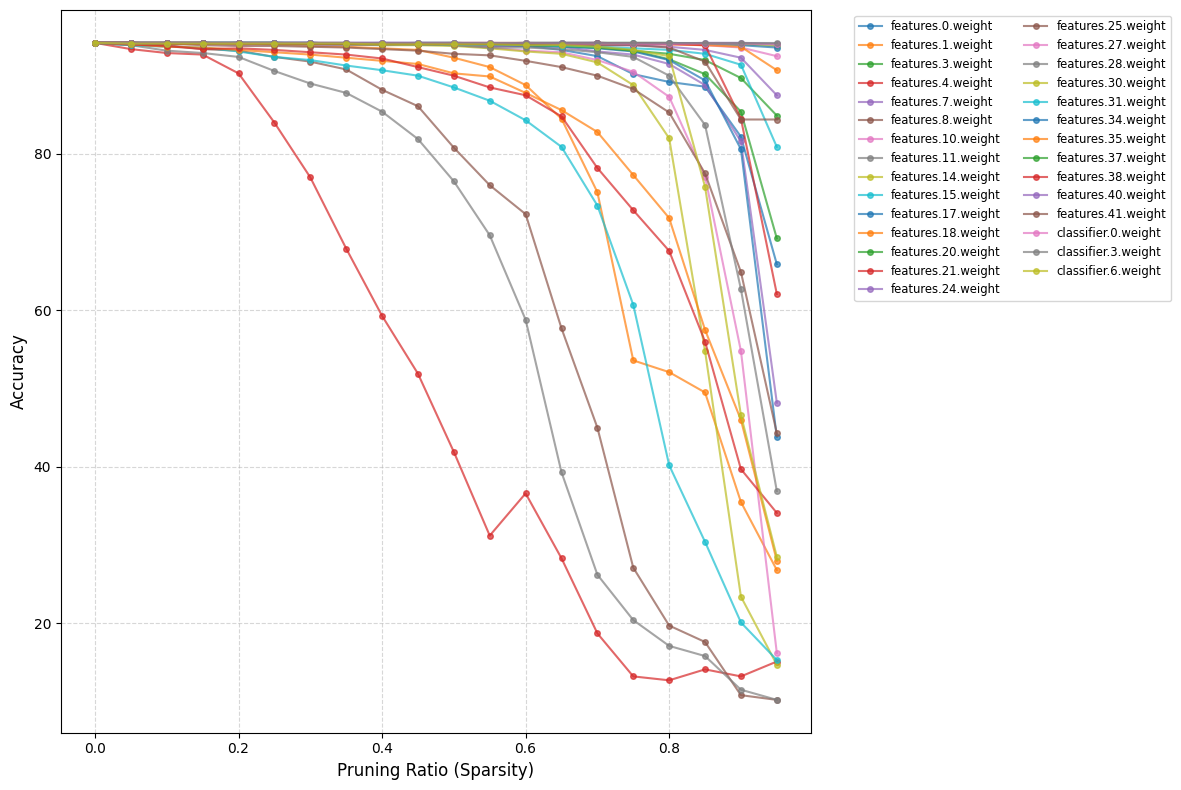

In [ ]:
mm.plot_sensitivity(results, org_acc)

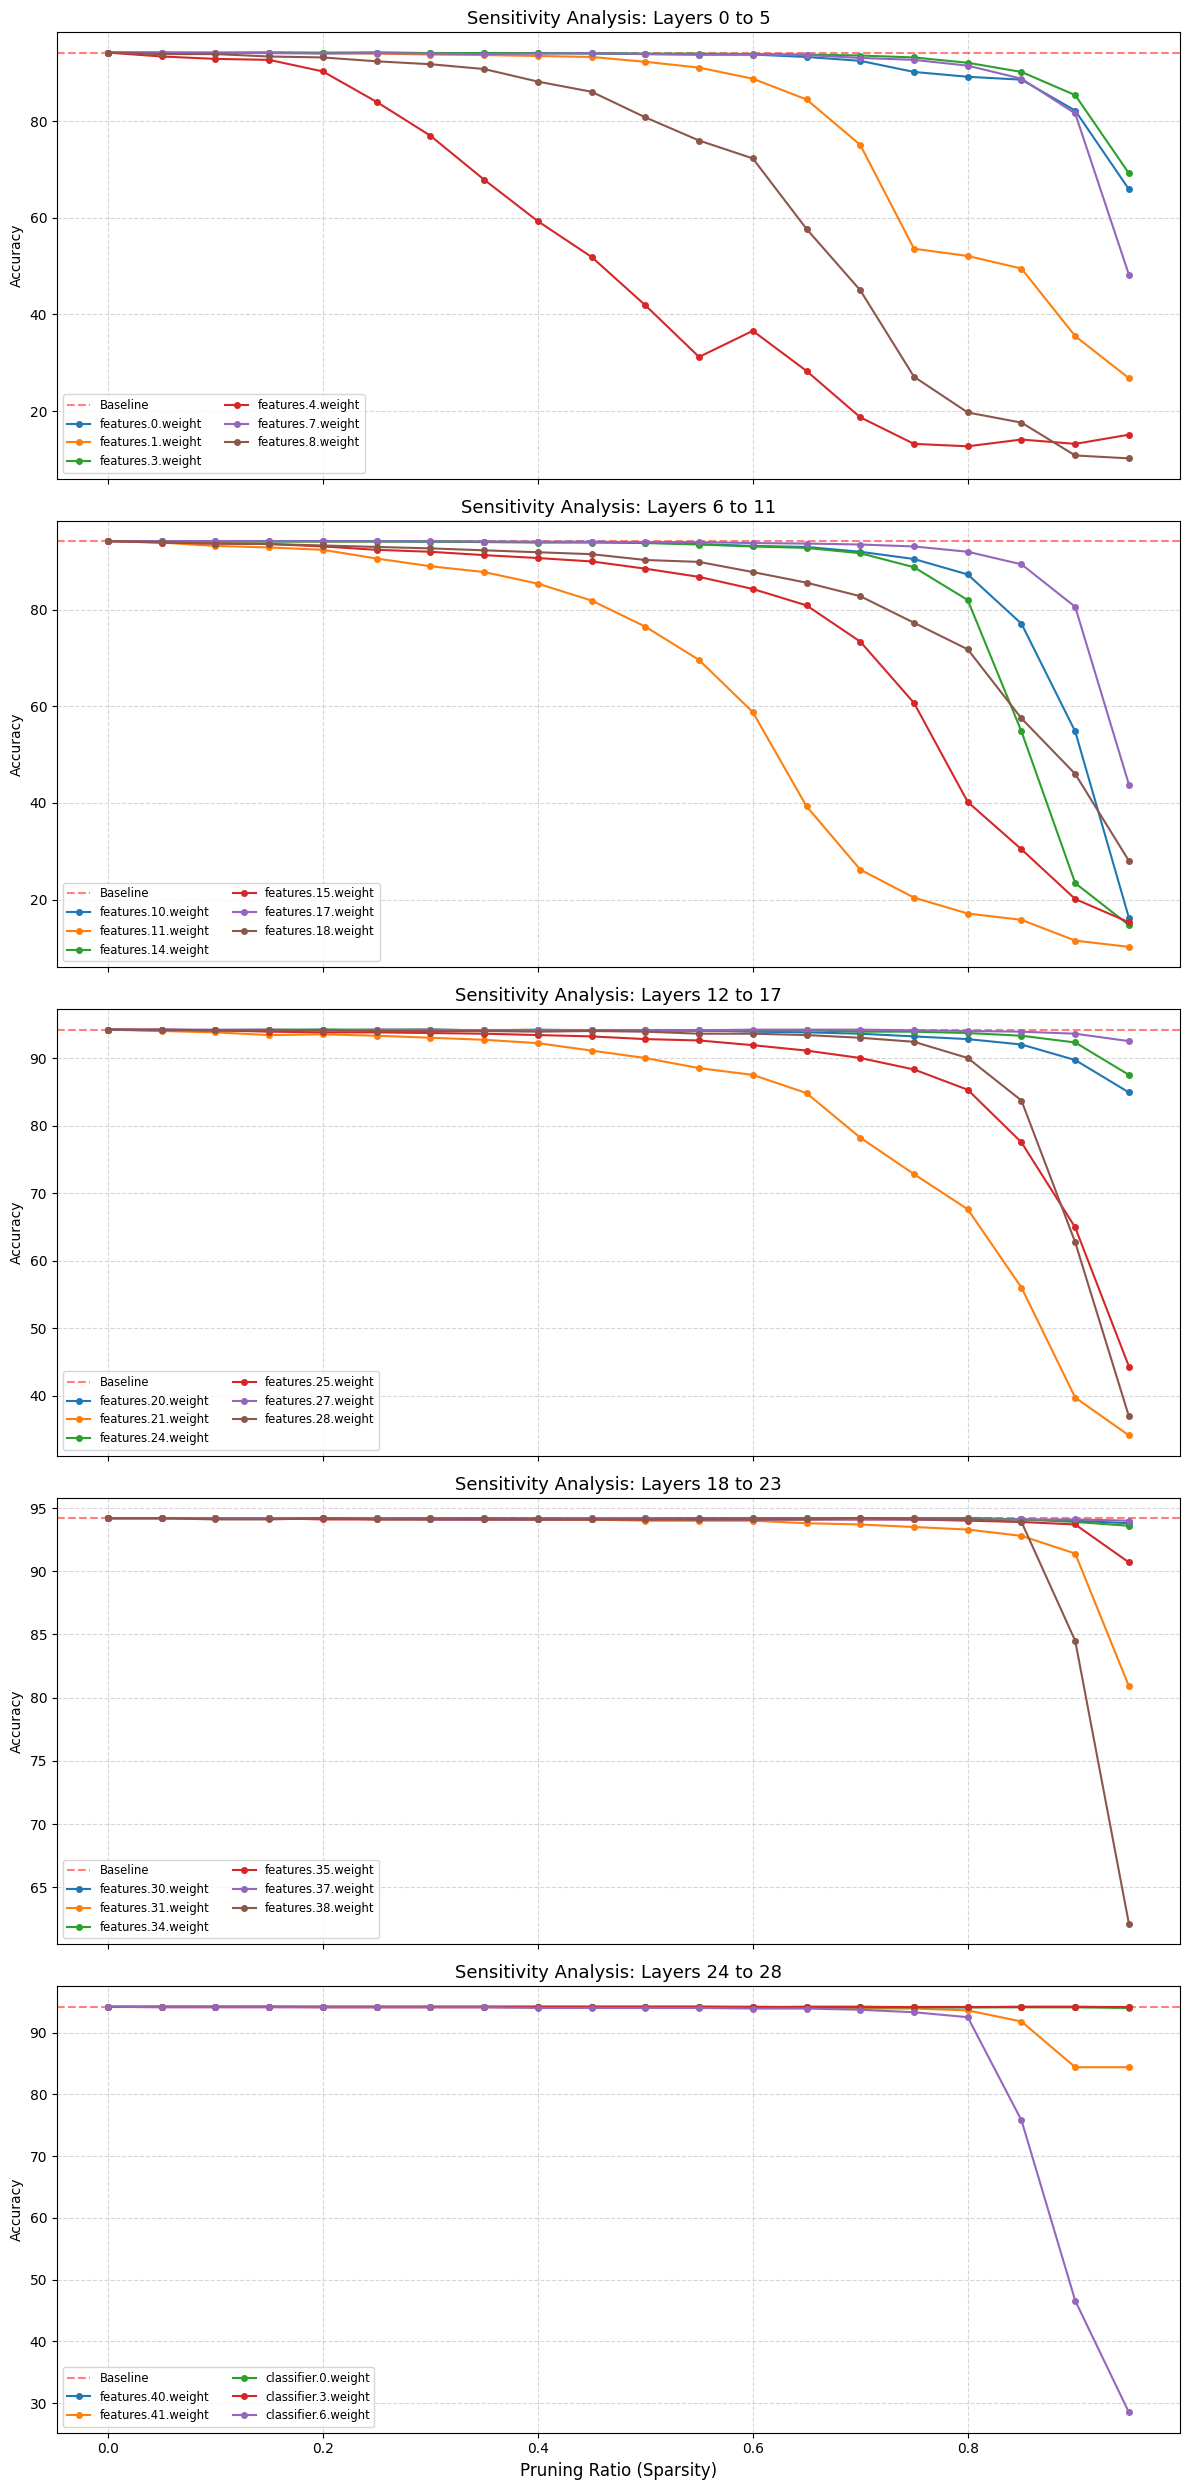

In [ ]:
mm.plot_sensitivity_subplots(results, org_acc)

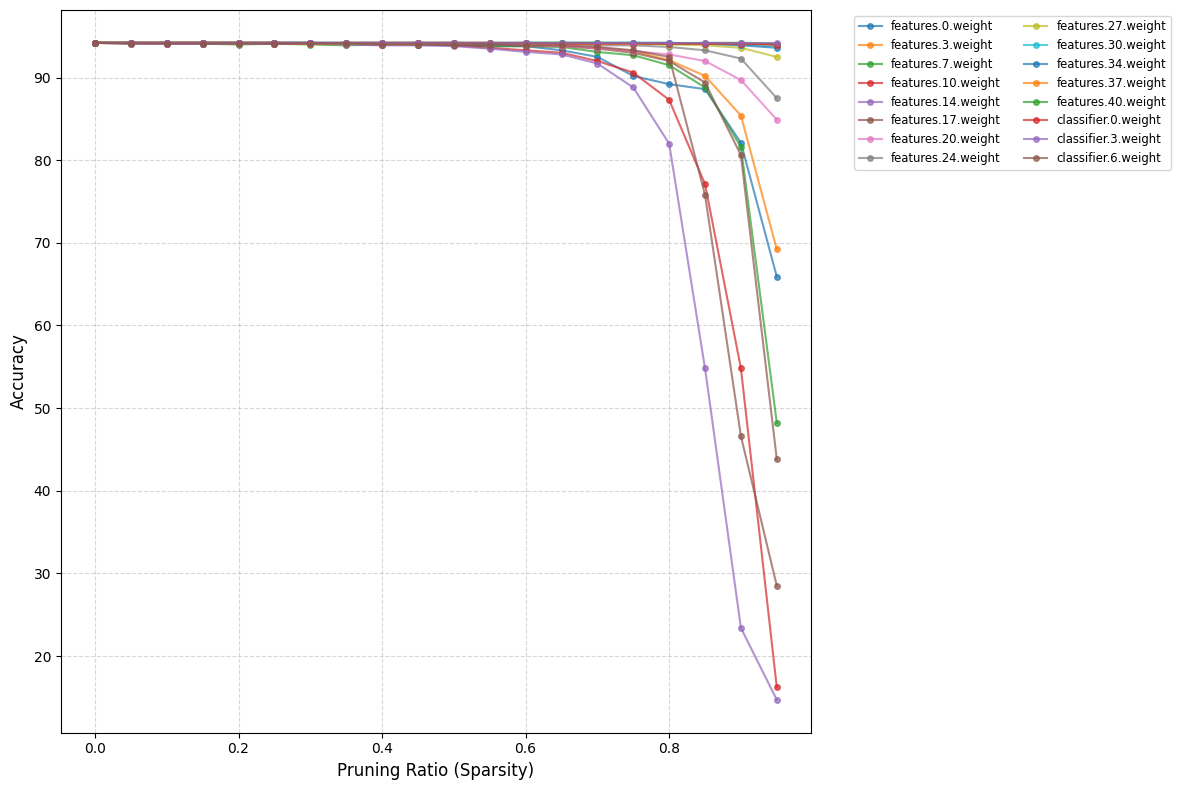

In [ ]:
#bn 없이
mm.plot_sensitivity(results, org_acc)

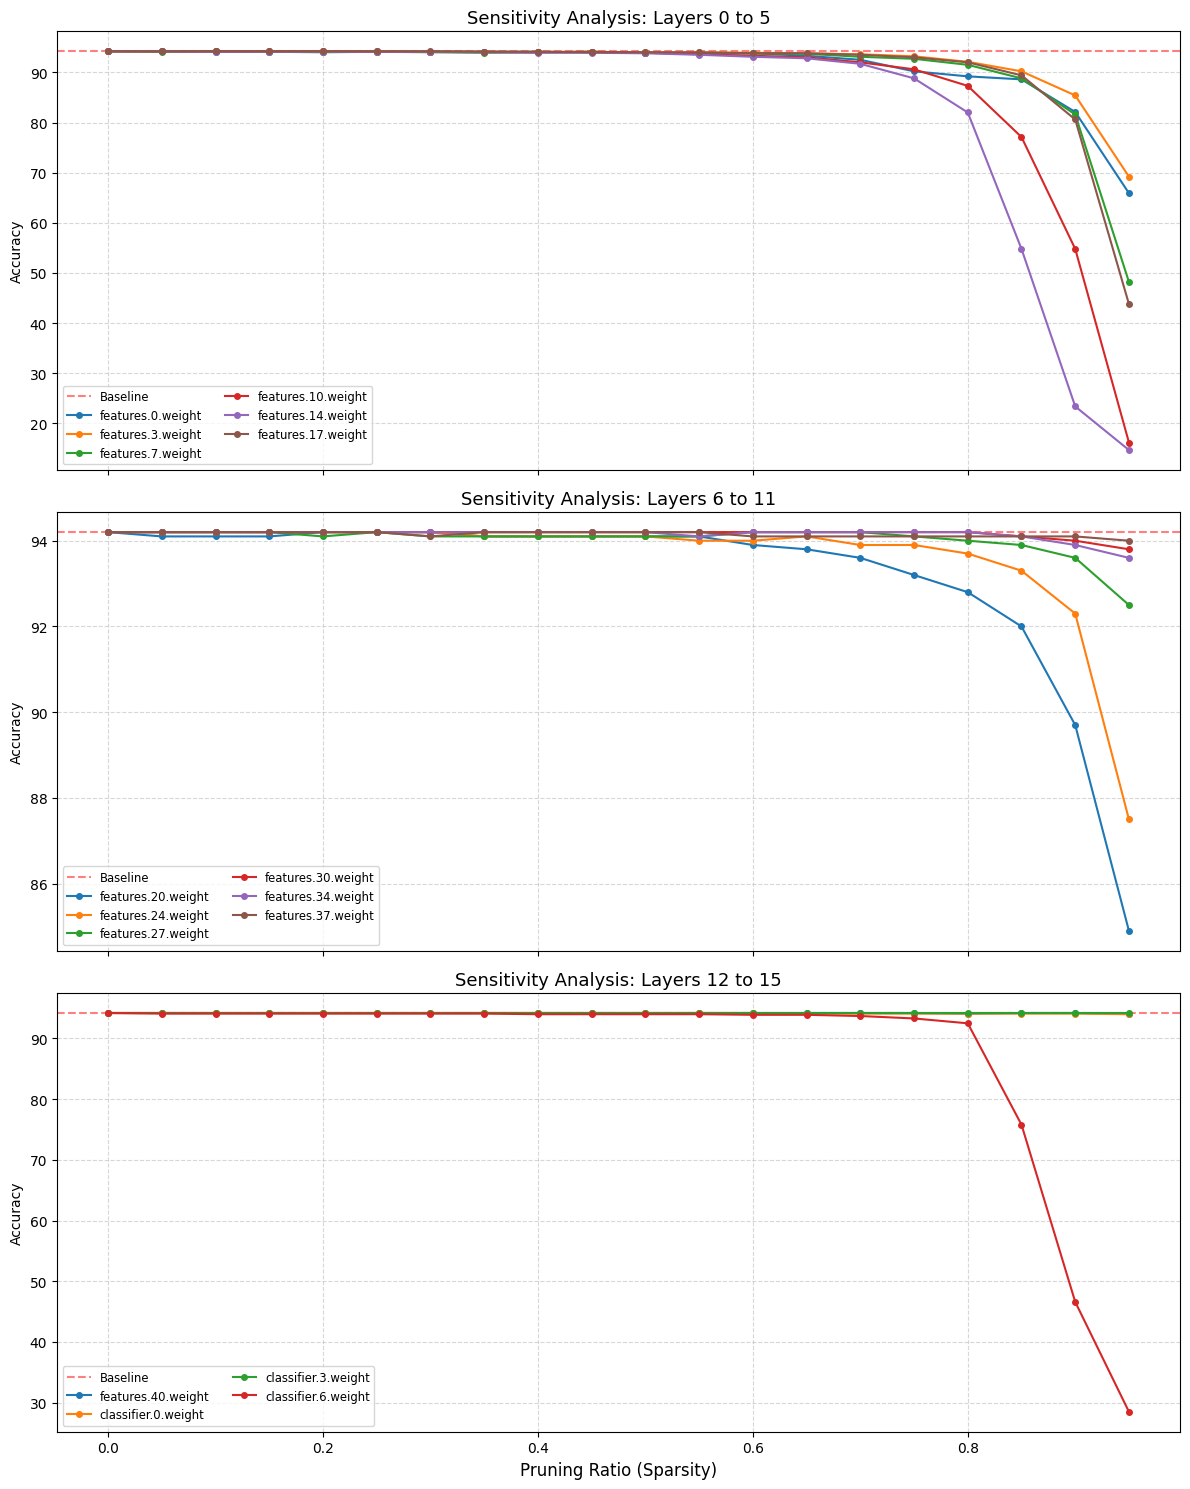

In [ ]:
#bn 없이
mm.plot_sensitivity_subplots(results, org_acc)

In [ ]:
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0]]
len(weight_param_list)
weight_param_list[28]
target_name,weight=weight_param_list[28]
print(target_name)
# print(weight)

weight_tensor=weight.data.clone()

val,idx=torch.sort(weight.view(-1,4))

pruned_model = copy.deepcopy(model)
params_dict = dict(pruned_model.named_parameters())

N,M=2,4

print(weight[0][:M])
print(weight.view(-1,M)[0])
print(val[0])

print(weight.view(-1,M).shape[0])
group=weight.view(-1,M).shape[0]

pruning_mask_flat=torch.ones_like(weight.view(-1,M), dtype=torch.float32)
pruning_mask_flat.shape

for g in range(group):
    # if g<20 : print(g,idx[g][:N])
    pruning_mask_flat[g][idx[g][:N]]=0
pruning_mask=pruning_mask_flat.reshape(weight.shape)
print(pruning_mask_flat[:20])

with torch.no_grad():
    # pruning weight 생성
    pruned_weight=weight_tensor*pruning_mask
    # pruning 적용
    params_dict[target_name].copy_(pruned_weight)

print(weight_tensor.shape,torch.sum(weight_tensor == 0).item(),torch.sum(pruned_weight == 0).item())

classifier.6.weight
tensor([-0.0970,  0.0290,  0.0581, -0.0183], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([-0.0970,  0.0290,  0.0581, -0.0183], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor([-0.0970, -0.0183,  0.0290,  0.0581], device='cuda:0',
       grad_fn=<SelectBackward0>)
1280
tensor([[0., 1., 1., 0.],
        [0., 0., 1., 1.],
        [0., 0., 1., 1.],
        [1., 0., 1., 0.],
        [0., 1., 0., 1.],
        [0., 1., 0., 1.],
        [0., 1., 0., 1.],
        [0., 1., 1., 0.],
        [1., 0., 1., 0.],
        [1., 1., 0., 0.],
        [0., 1., 1., 0.],
        [1., 0., 0., 1.],
        [1., 1., 0., 0.],
        [0., 1., 1., 0.],
        [0., 1., 0., 1.],
        [0., 1., 0., 1.],
        [0., 1., 0., 1.],
        [1., 0., 0., 1.],
        [1., 0., 1., 0.],
        [1., 1., 0., 0.]], device='cuda:0')
torch.Size([10, 512]) 0 2560


In [ ]:
results,org_acc=mm.PSA_NM(model,test_DL, DEVICE)

# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_nm(34)_re_results_torch.pt')

# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")

Test accuracy: 9416/10000 (94.2 %)
Test accuracy: 8056/10000 (80.6 %)
Progress: 6.25%
Test accuracy: 7384/10000 (73.8 %)
Progress: 12.50%
Test accuracy: 8979/10000 (89.8 %)
Progress: 18.75%
Test accuracy: 7411/10000 (74.1 %)
Progress: 25.00%
Test accuracy: 7889/10000 (78.9 %)
Progress: 31.25%
Test accuracy: 9016/10000 (90.2 %)
Progress: 37.50%
Test accuracy: 9310/10000 (93.1 %)
Progress: 43.75%
Test accuracy: 9350/10000 (93.5 %)
Progress: 50.00%
Test accuracy: 9376/10000 (93.8 %)
Progress: 56.25%
Test accuracy: 9411/10000 (94.1 %)
Progress: 62.50%
Test accuracy: 9405/10000 (94.0 %)
Progress: 68.75%
Test accuracy: 9413/10000 (94.1 %)
Progress: 75.00%
Test accuracy: 9420/10000 (94.2 %)
Progress: 81.25%
Test accuracy: 9409/10000 (94.1 %)
Progress: 87.50%
Test accuracy: 9419/10000 (94.2 %)
Progress: 93.75%
Test accuracy: 9373/10000 (93.7 %)
Progress: 100.00%
Results saved to /content/drive/MyDrive//pytorch_practice/checkpoints/./saved_results/psa_nm(34)_re_results_torch.pt


In [ ]:
# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
# os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_nm_results_torch.pt')

# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")

Results saved to g:\내 드라이브\02_학업\02_연구 및 프로젝트\2512-2602_Dash 연구인턴\pytorch_practice\checkpoints\./saved_results\psa_nm_results_torch.pt


In [ ]:
file_path_torch = os.path.join(output_dir, 'psa_nm_re_results_torch.pt')

# 저장된 'results' 딕셔너리 불러오기
with open(file_path_torch, 'rb') as f:
    results = torch.load(f)
print(f"Results loaded from {file_path_torch}")

# 불러온 데이터 확인 (일부)
print("Loaded results (first layer): ", results[list(results.keys())[0]])

Results loaded from /content/drive/MyDrive//pytorch_practice/checkpoints/./saved_results/psa_nm_re_results_torch.pt
Loaded results (first layer):  94.2


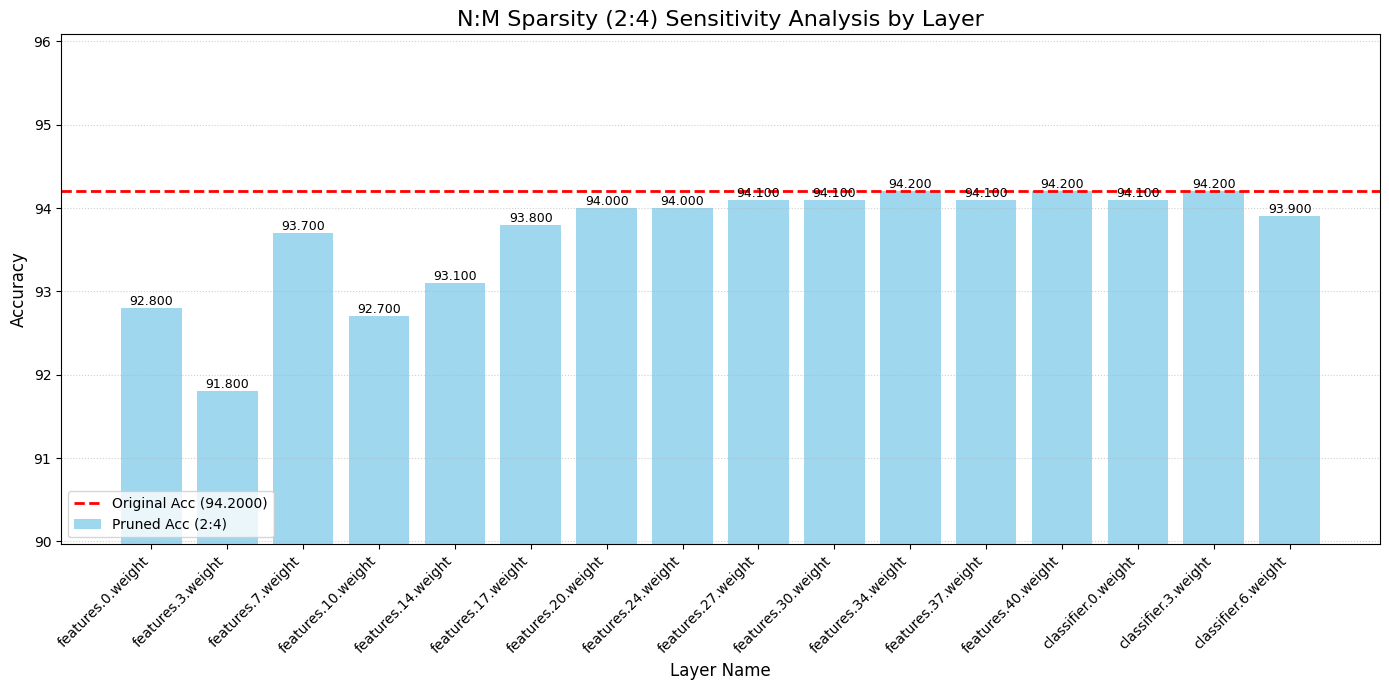

In [ ]:
mm.plot_nm_sensitivity(results,org_acc, n_m_str="2:4")

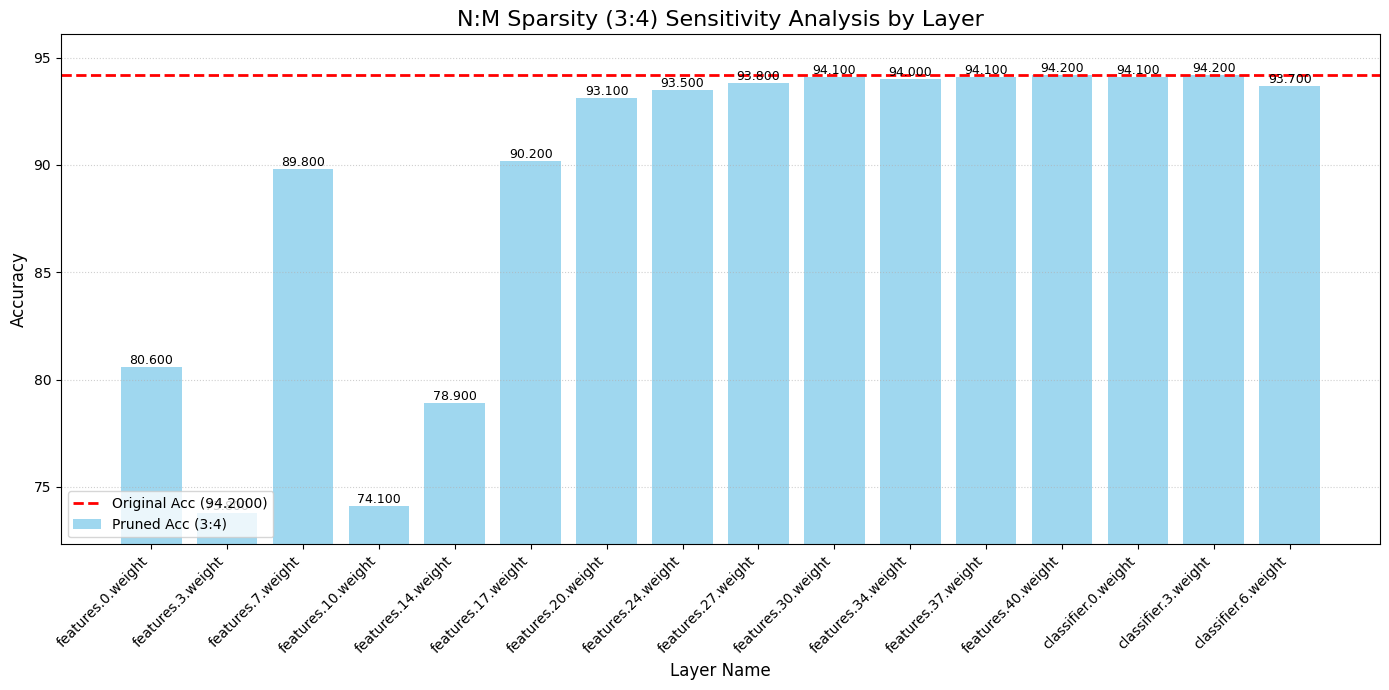

In [ ]:
mm.plot_nm_sensitivity(results,org_acc, n_m_str="3:4")

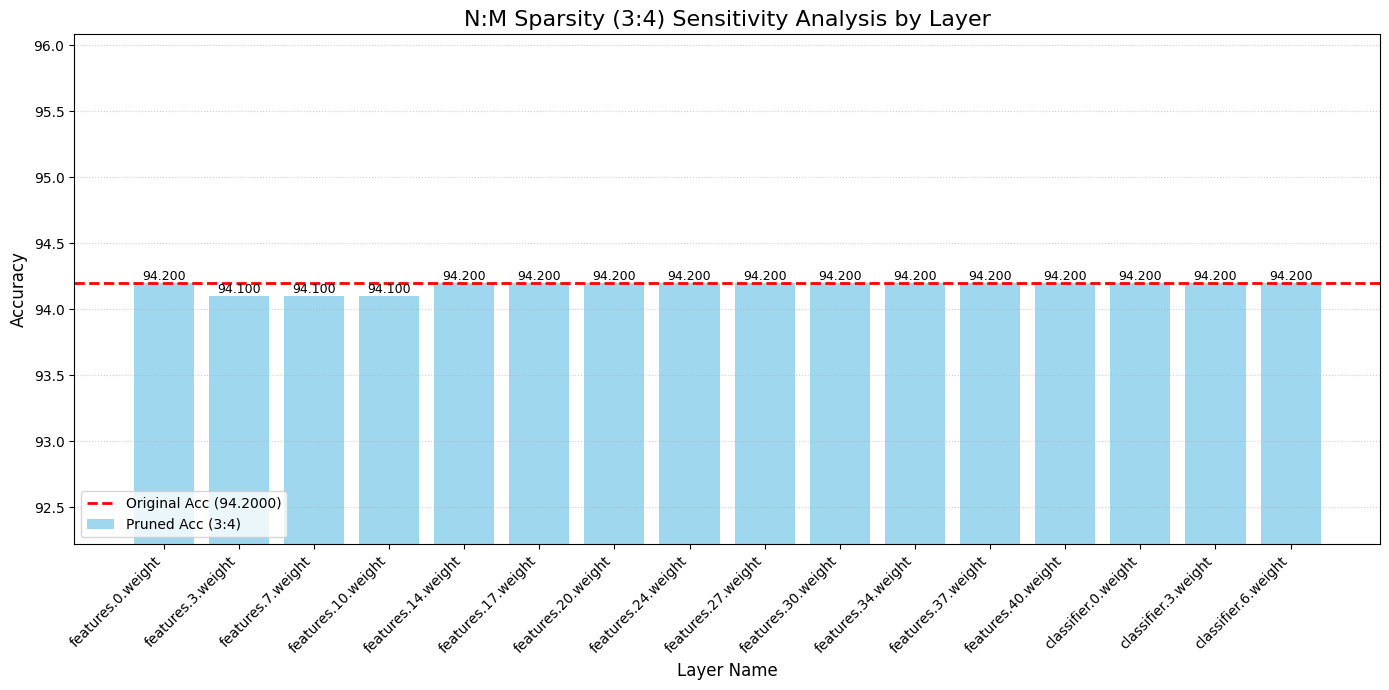

In [ ]:
# 3:4
mm.plot_nm_sensitivity(results,org_acc, n_m_str="3:4")

In [ ]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [ ]:
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0]and p[1].dim() ==4]
print(len(weight_param_list))
# for i in range(len(weight_param_list)):
#     print(i, weight_param_list[i][0],weight_param_list[i][1].shape)
name,weight=weight_param_list[0]
print(name)
print(weight.shape)


weight_tensor=weight.data.clone()
print(weight.view(-1,3).shape)
print(torch.sum(torch.abs(weight.view(-1,3)),dim=1).shape)

print(weight.view(-1,3)[:5])
print(torch.sum(torch.abs(weight.view(-1,3)),dim=1)[:5])

l1_mag=torch.abs(weight_tensor)
val,idx=torch.sort(torch.sum(torch.abs(l1_mag.view(-1,3)),dim=1))
print(idx.shape)
group=idx.shape[0]
print(group)
ratio=0.5
n_prune = int(group * ratio)



# pruning 마스크 생성
pruning_mask=torch.ones_like(l1_mag.view(-1,3), dtype=torch.float32)
print(pruning_mask.shape)
# print([0,1,2,3])
pruning_mask[[0,1,2,3]]=0
print(pruning_mask[:10])
# pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)

# with torch.no_grad():
#     # pruning weight 생성
#     pruned_weight=weight_tensor*pruning_mask
#     # pruning 적용
#     params_dict[target_name].copy_(pruned_weight)



13
features.0.weight
torch.Size([64, 3, 3, 3])
torch.Size([576, 3])
torch.Size([576])
tensor([[-0.0095, -0.0105, -0.0097],
        [-0.0072, -0.0081, -0.0146],
        [-0.0051, -0.0052, -0.0116],
        [ 0.0033,  0.0035,  0.0033],
        [ 0.0092,  0.0095,  0.0018]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([0.0296, 0.0299, 0.0219, 0.0101, 0.0205], device='cuda:0',
       grad_fn=<SliceBackward0>)
torch.Size([576])
576
torch.Size([576, 3])
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], device='cuda:0')


In [ ]:
results,org_acc=mm.PSA_vector(model,test_DL, DEVICE)

# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_vector_re_results_torch.pt')


# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")

Test accuracy: 9416/10000 (94.2 %)
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9416/10000 (94.2 %)
Progress: 0.00%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9415/10000 (94.2 %)
Progress: 0.38%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9415/10000 (94.2 %)
Progress: 0.77%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9414/10000 (94.1 %)
Progress: 1.15%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9413/10000 (94.1 %)
Progress: 1.54%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9409/10000 (94.1 %)
Progress: 1.92%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9406/10000 (94.1 %)
Progress: 2.31%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9388/10000 (93.9 %)
Progress: 2.69%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Test accuracy: 9378/10000 (93.8 %)
Progress: 3.08%
torch.Size([64, 3, 3, 3]) torch.Size([

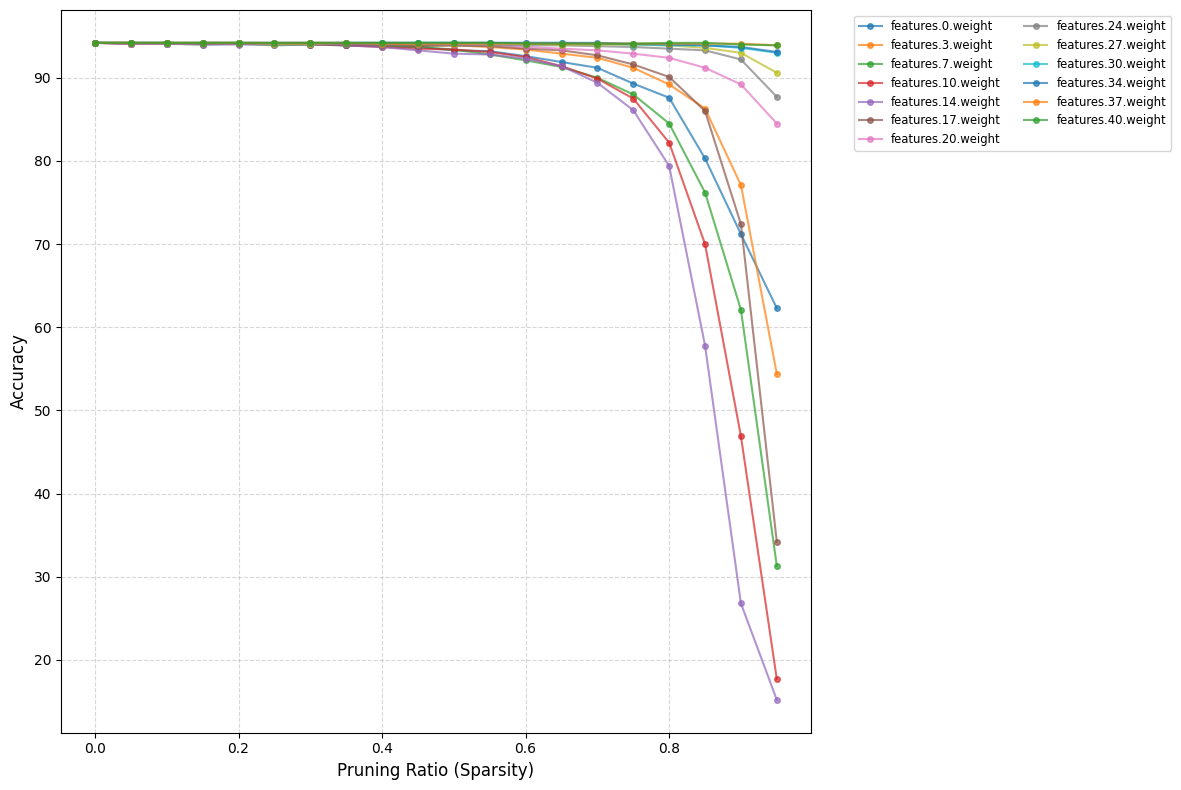

In [ ]:
mm.plot_sensitivity(results, org_acc)

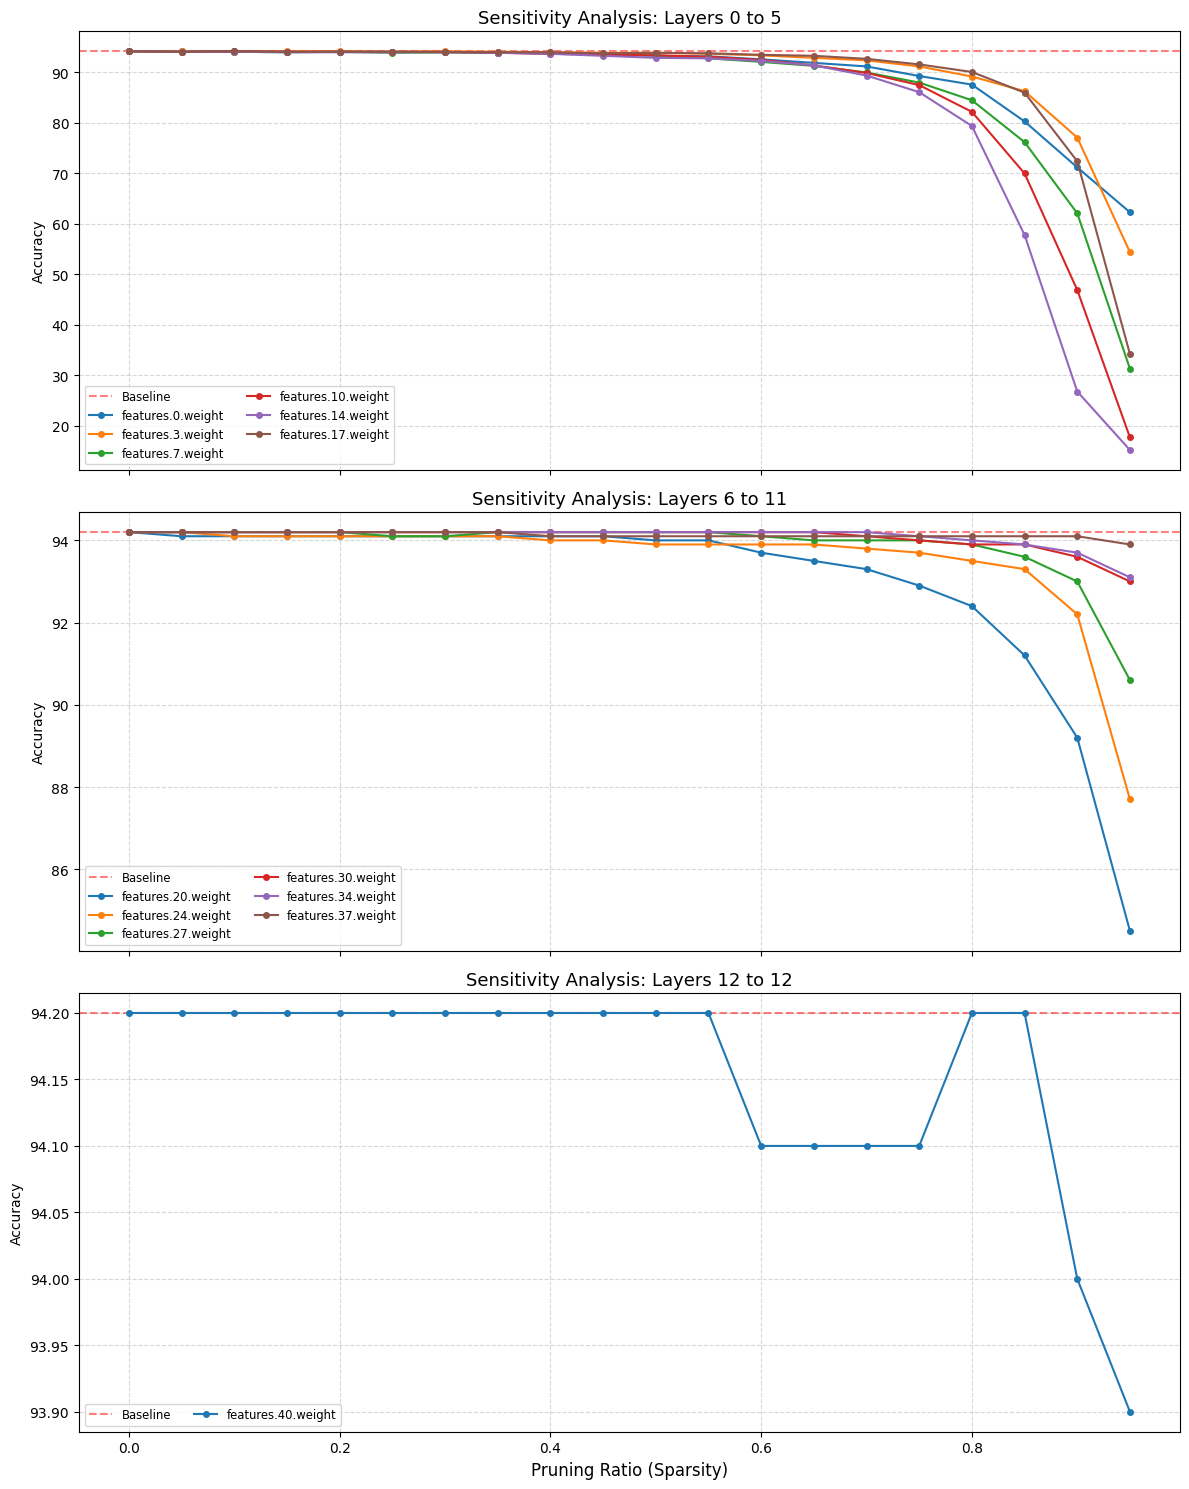

In [ ]:
mm.plot_sensitivity_subplots(results, org_acc)

In [ ]:
results,org_acc=mm.PSA_kernel(model,test_DL, DEVICE)

# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_kernel_re_results_torch.pt')


# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")

torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 0.00%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 0.38%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 0.77%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 1.15%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 1.54%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 1.92%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 2.31%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 2.69%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 3.08%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 3.46%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 3.85%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 4.23%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 4.62%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 3])
Progress: 5.00%
torch.Size([64, 3, 3, 3]) torch.Size([64, 3, 3, 

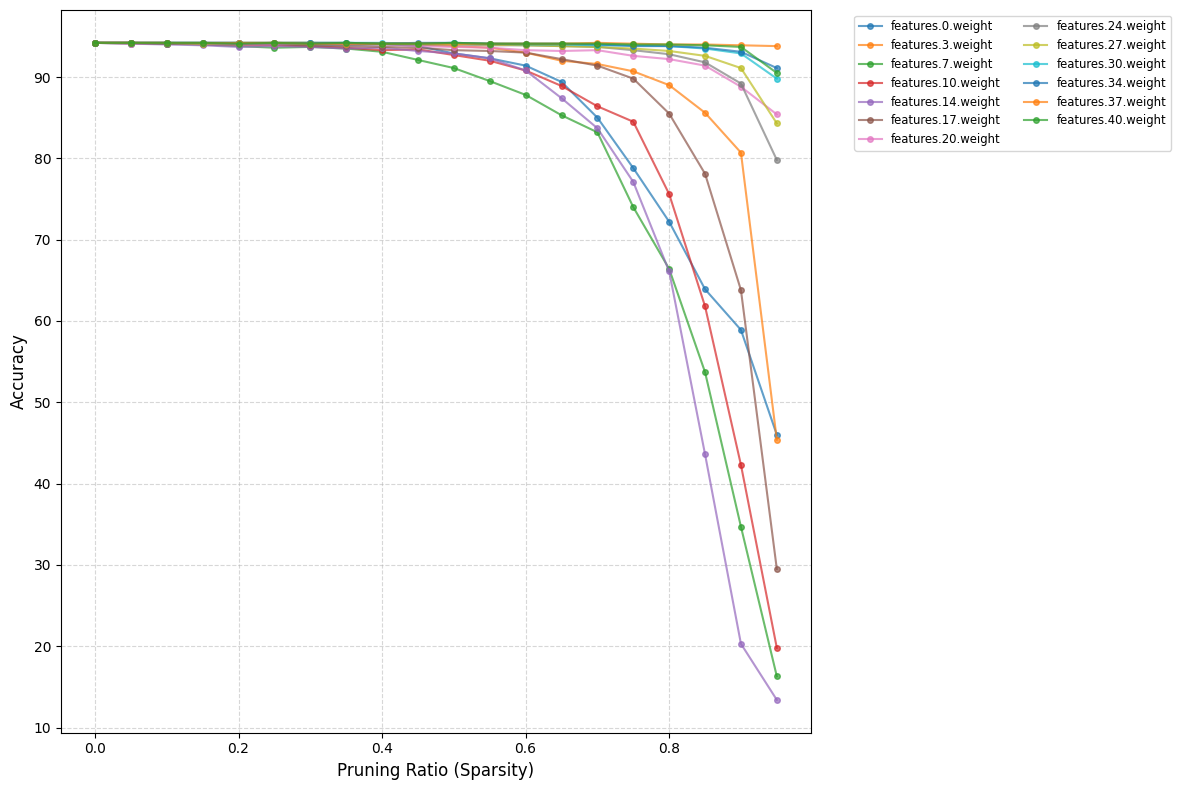

In [ ]:
mm.plot_sensitivity(results, org_acc)

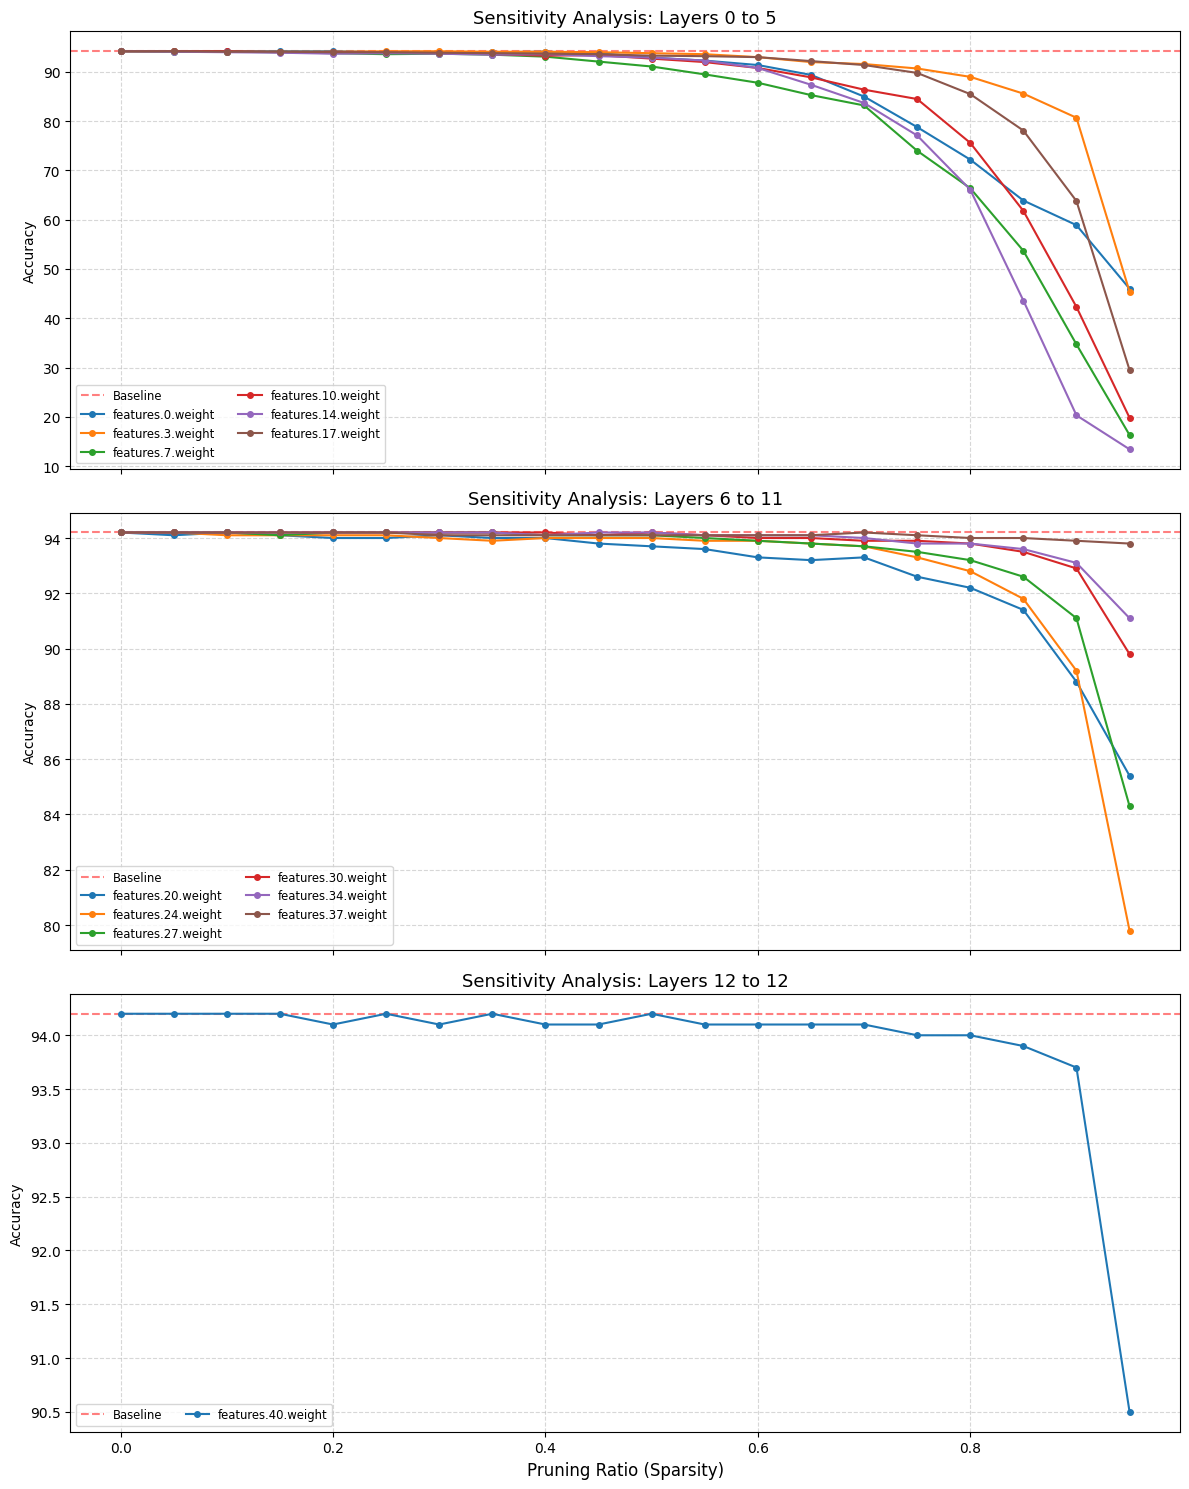

In [ ]:
mm.plot_sensitivity_subplots(results, org_acc)

In [ ]:
results,org_acc=mm.PSA_channel(model,test_DL, DEVICE)

# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_channel_re_results_torch.pt')


# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")


Results saved to /content/drive/MyDrive/02_학업/02_연구 및 프로젝트/2512-2602_Dash 연구인턴/pytorch_practice/checkpoints/./saved_results/psa_channel_re_results_torch.pt


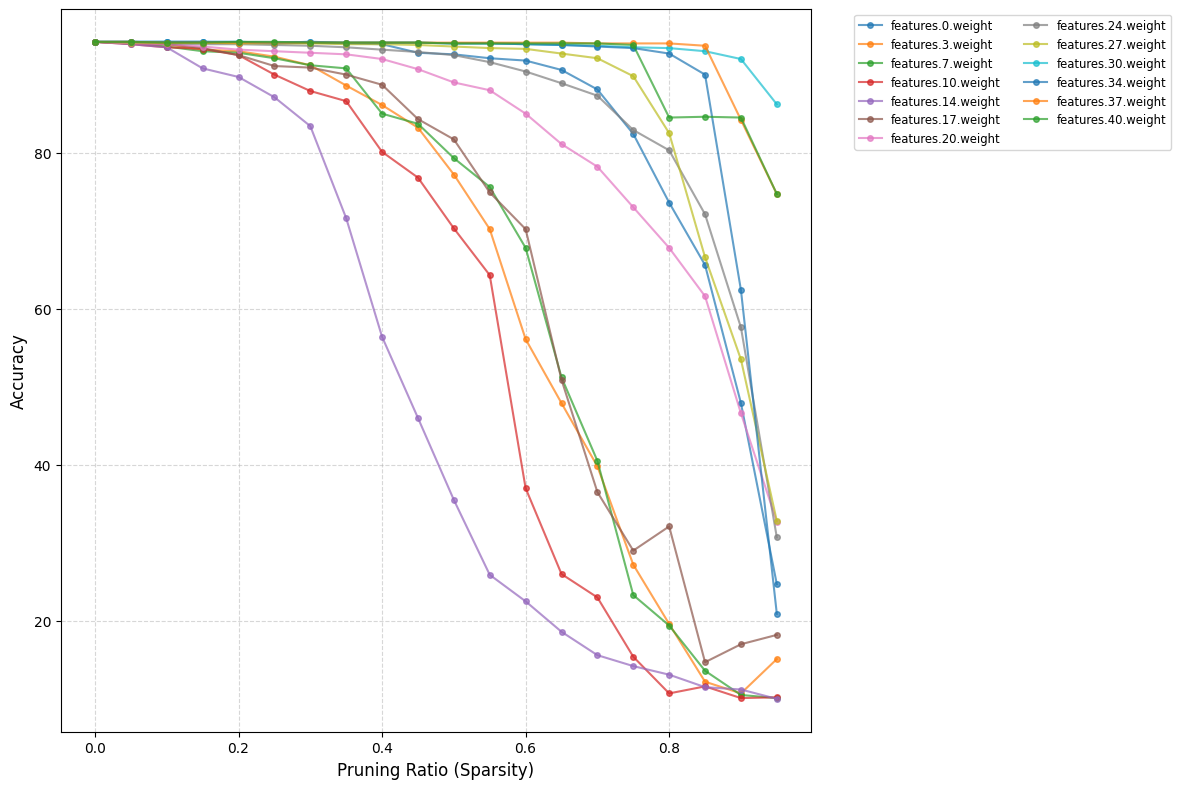

In [ ]:
mm.plot_sensitivity(results, org_acc)

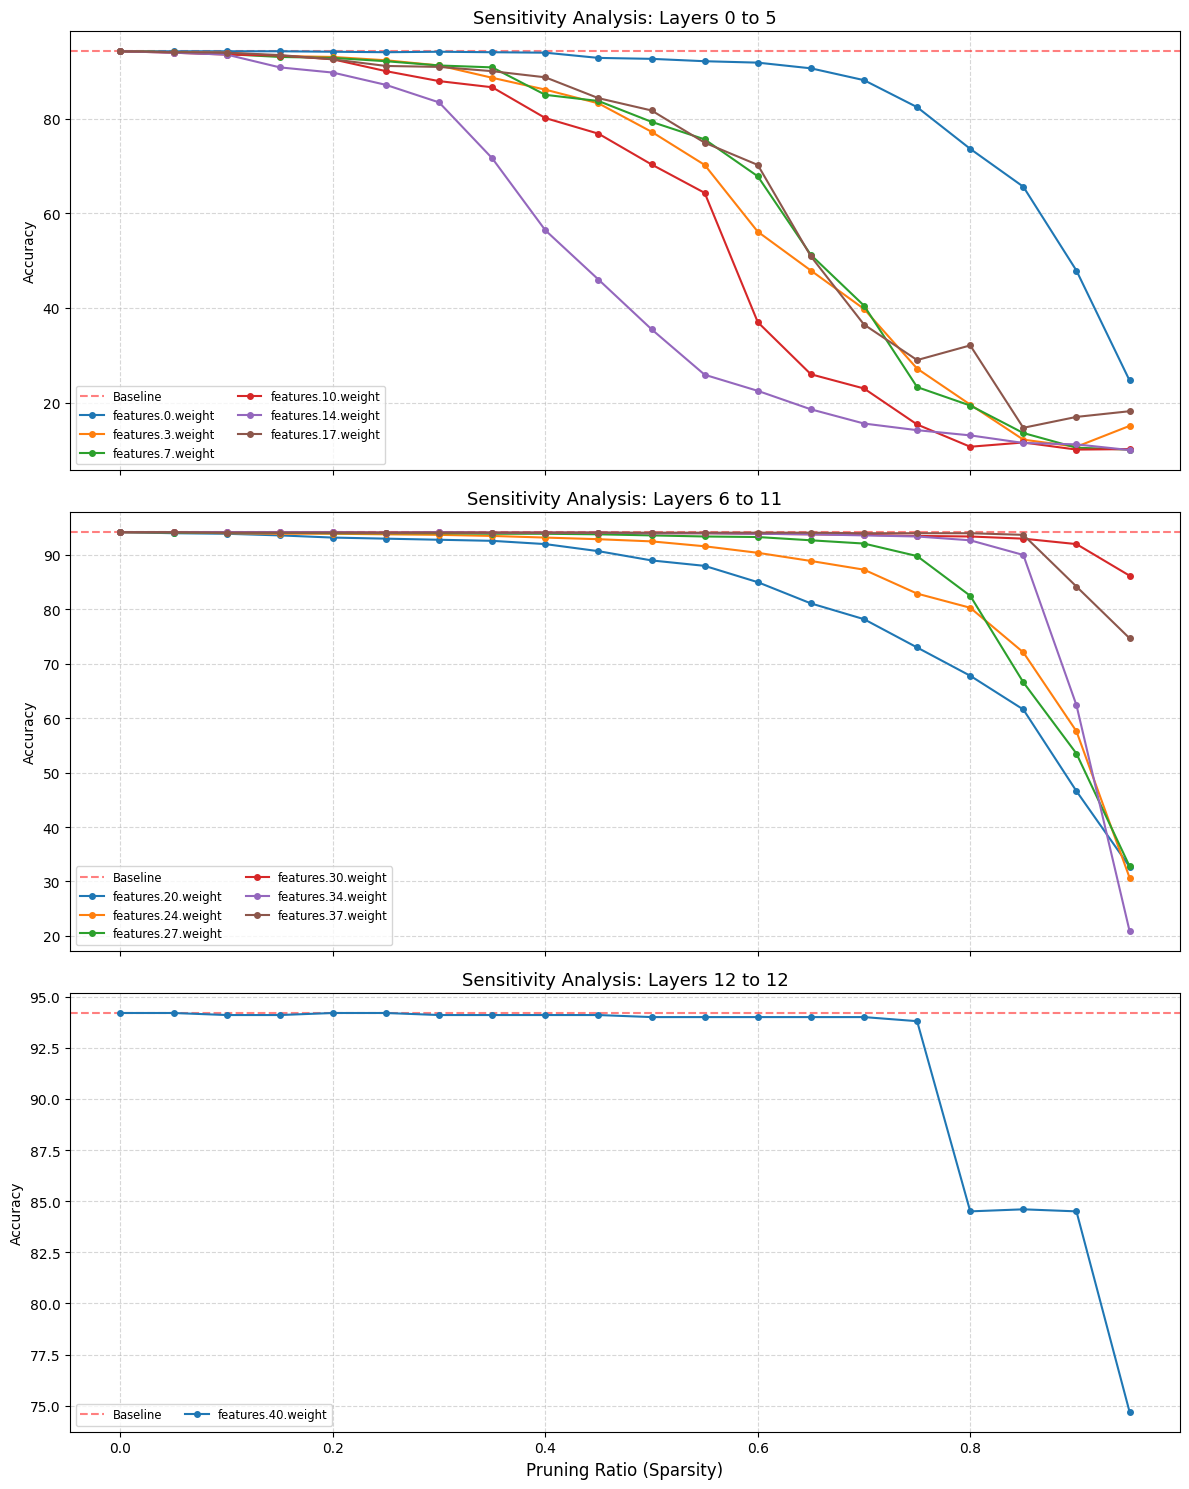

In [ ]:
mm.plot_sensitivity_subplots(results, org_acc)

In [ ]:
results,org_acc=mm.PSA_scaling(model,test_DL, DEVICE)

# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_scaling_re_results_torch.pt')


# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")

Sensitivity Analysis:   0%|          | 0/260 [00:00<?, ?it/s]

Results saved to /content/drive/MyDrive/02_학업/02_연구 및 프로젝트/2512-2602_Dash 연구인턴/pytorch_practice/checkpoints/./saved_results/psa_scaling_re_results_torch.pt


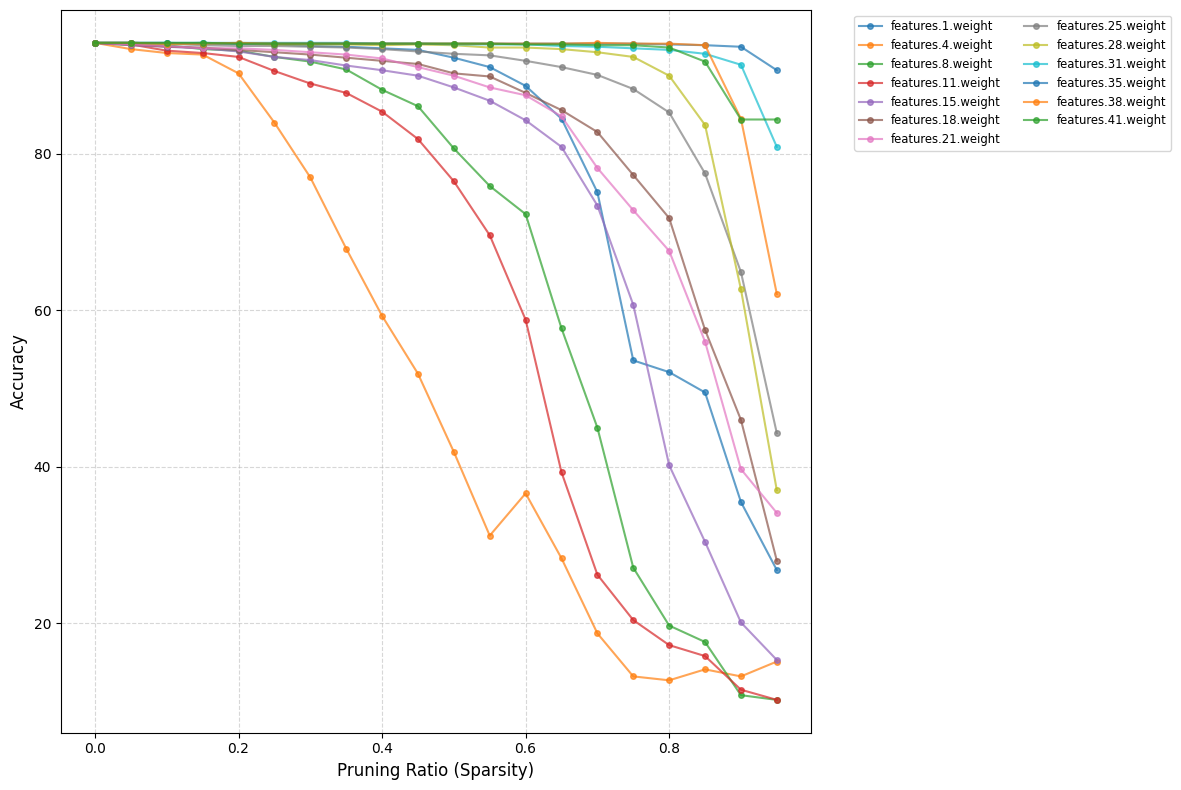

In [ ]:
mm.plot_sensitivity(results, org_acc)

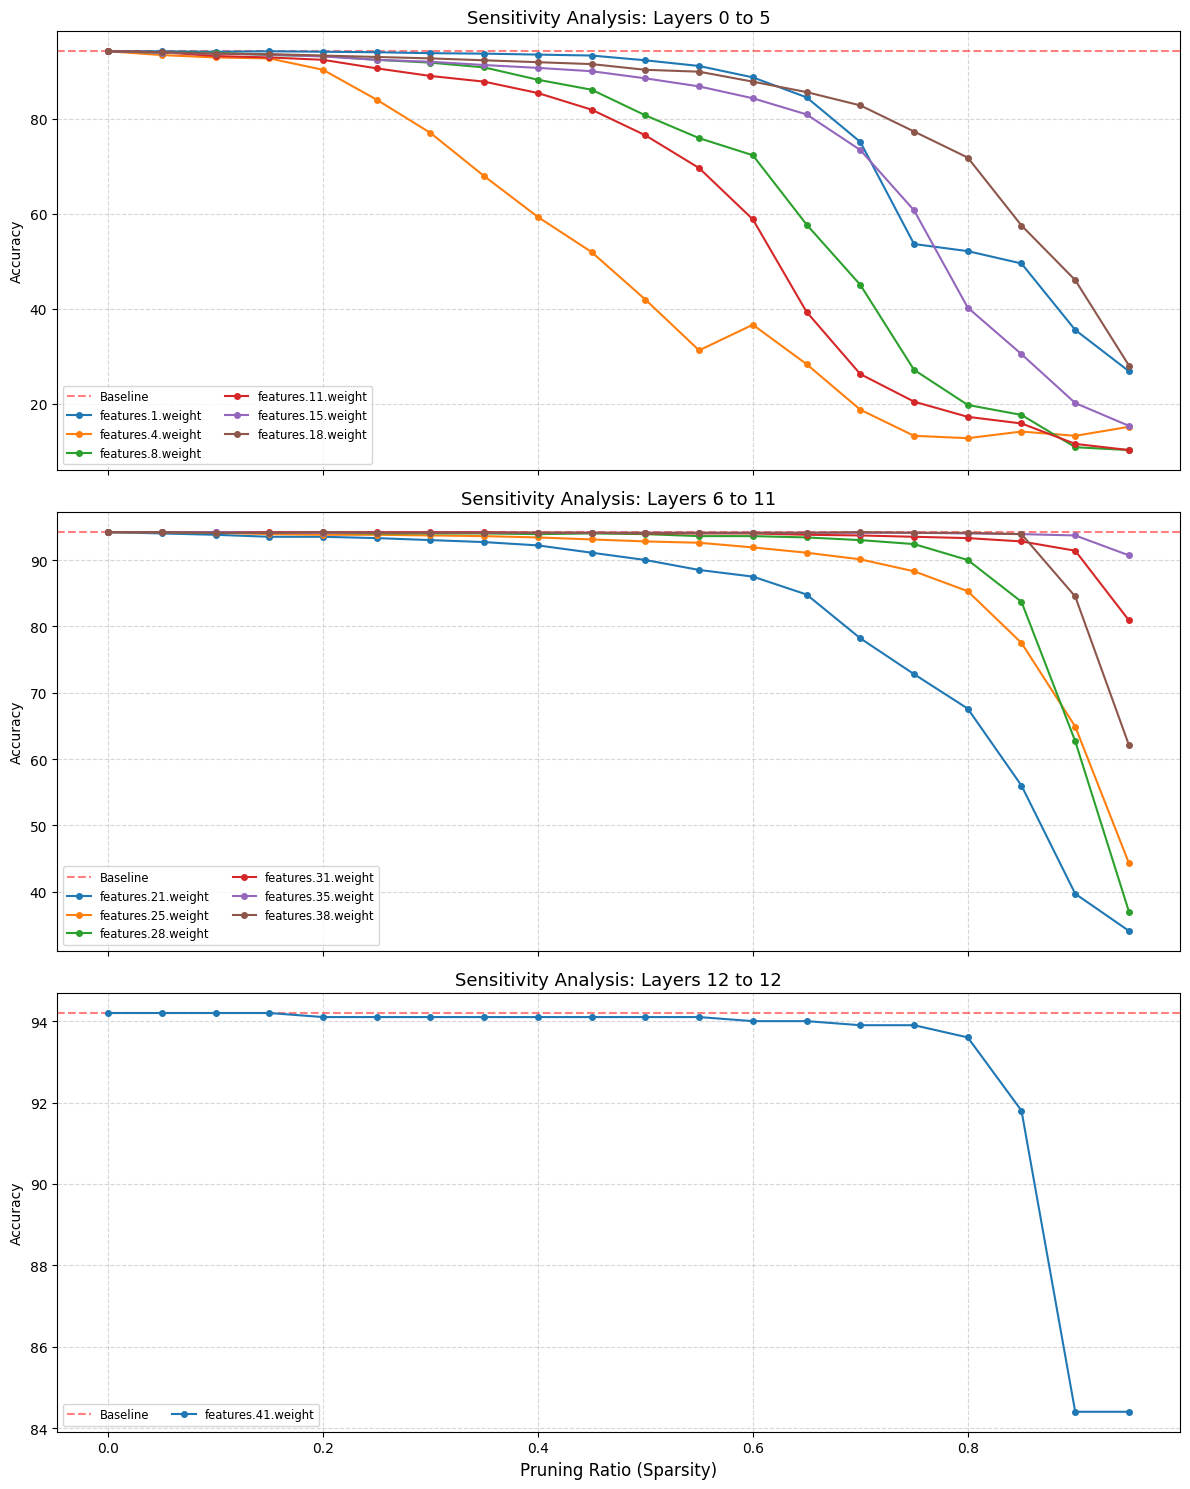

In [ ]:
mm.plot_sensitivity_subplots(results, org_acc)